Using device: cuda


C:\Users\niles\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 0.44169
Epoch 500, Loss: 0.00021
Epoch 1000, Loss: 0.00003
Epoch 1500, Loss: 0.00023
Epoch 2000, Loss: 0.00002
Epoch 2500, Loss: 0.00009
Epoch 3000, Loss: 0.00001
Epoch 3500, Loss: 0.00001
Epoch 4000, Loss: 0.00007
Epoch 4500, Loss: 0.00001


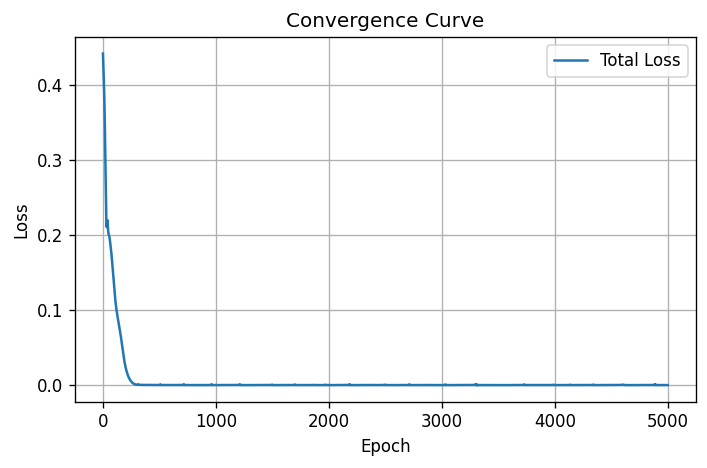

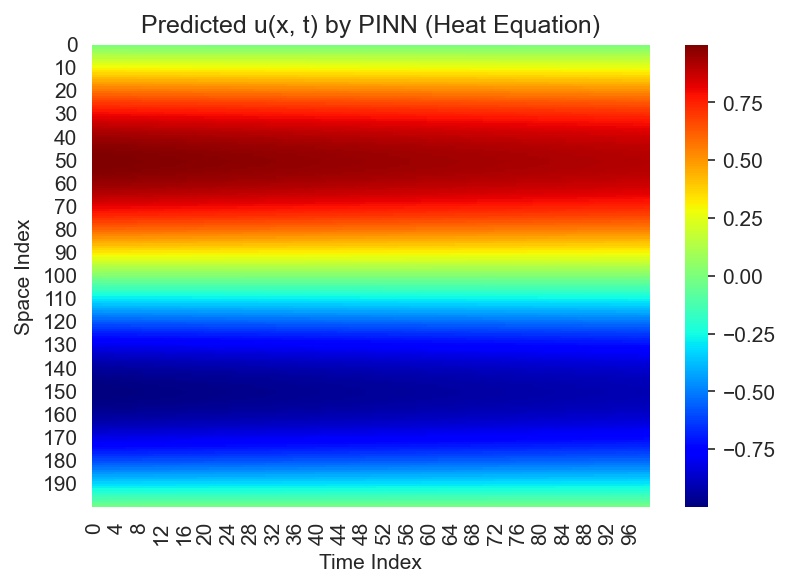

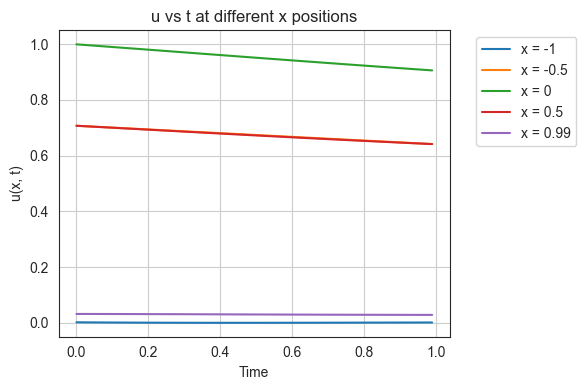

In [1]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Step 1: Define a Simple Neural Network
class SimpleNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=20, output_size=1, depth=4):
        super(SimpleNN, self).__init__()
        layers = [nn.Linear(input_size, hidden_size), nn.Tanh()]
        for _ in range(depth):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Step 2: Define the Physics-Informed Neural Network (PINN)
class PINN:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        self.model = SimpleNN().to(self.device)

        h = self.h = 0.01
        k = self.k = 0.1

        x = torch.arange(-1, 1 + h, h)
        t = torch.arange(0, 1 + k, k)
        self.x = x
        self.t = t

        self.X = torch.stack(torch.meshgrid(x, t, indexing='ij')).reshape(2, -1).T.to(self.device)

        # Boundary conditions: u(-1, t) = 0 and u(1, t) = 0
        bc1 = torch.stack(torch.meshgrid(x[:1], t, indexing='ij')).reshape(2, -1).T
        bc2 = torch.stack(torch.meshgrid(x[-1:], t, indexing='ij')).reshape(2, -1).T

        # Initial condition: u(x, 0) = -sin(pi * x)
        ic = torch.stack(torch.meshgrid(x, t[:1], indexing='ij')).reshape(2, -1).T

        self.X_train = torch.cat([bc1, bc2, ic]).to(self.device)
        self.y_train = torch.cat([
            torch.zeros(len(bc1)),
            torch.zeros(len(bc2)),
            -torch.sin(math.pi * ic[:, 0])
        ]).unsqueeze(1).to(self.device)

        self.X.requires_grad = True
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.loss_history = []  # <-- initialize here

    def loss_function(self):
        y_pred = self.model(self.X_train)
        loss_data = self.criterion(y_pred, self.y_train)

        u = self.model(self.X)
        grads = torch.autograd.grad(u, self.X, torch.ones_like(u), create_graph=True)[0]
        du_dt, du_dx = grads[:, 1], grads[:, 0]
        du_dxx = torch.autograd.grad(du_dx, self.X, torch.ones_like(du_dx), create_graph=True)[0][:, 0]

        alpha = 0.01
        loss_pde = self.criterion(du_dt, alpha * du_dxx)

        return loss_data + loss_pde

    def train(self, epochs=5000):
        self.loss_history = []  # <-- reset at the start
        for i in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss_function()
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())  # <-- record loss

            if i % 500 == 0:
                print(f"Epoch {i}, Loss: {loss.item():.5f}")

    def predict(self, x, t):
        X_test = torch.stack(torch.meshgrid(x, t, indexing='ij')).reshape(2, -1).T.to(self.device)
        with torch.no_grad():
            y_pred = self.model(X_test).cpu().numpy().reshape(len(x), len(t))
        return y_pred

# Step 3: Train and Visualize
pinn = PINN()
pinn.train()

# Predict
x = torch.arange(-1, 1, 0.01)
t = torch.arange(0, 1, 0.01)
y_pred = pinn.predict(x, t)

# Plot: Convergence Curve
plt.figure(figsize=(6, 4), dpi=120)
plt.plot(pinn.loss_history, label='Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convergence Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Heatmap
sns.set_style("white")
plt.figure(figsize=(6, 4), dpi=150)
sns.heatmap(y_pred, cmap='jet')
plt.title("Predicted u(x, t) by PINN (Heat Equation)")
plt.xlabel("Time Index")
plt.ylabel("Space Index")
plt.show()

# Plot: u vs t at selected x positions
x_positions = [0, 25, 50, 75, 99]
x_labels = ['-1', '-0.5', '0', '0.5', '0.99']

plt.figure(figsize=(6, 4))
for xi, label in zip(x_positions, x_labels):
    plt.plot(t, y_pred[xi, :], label=f'x = {label}')
plt.title("u vs t at different x positions")
plt.xlabel("Time")
plt.ylabel("u(x, t)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# Animation of u(x, t) over time
fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot(x, y_pred[:, 0])
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('Solution evolution over time')
ax.grid(True)

def update(frame):
    line.set_ydata(y_pred[:, frame])
    ax.set_title(f'Solution at t = {t[frame]:.2f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(t), interval=50, blit=True)
plt.close()
HTML(ani.to_jshtml())

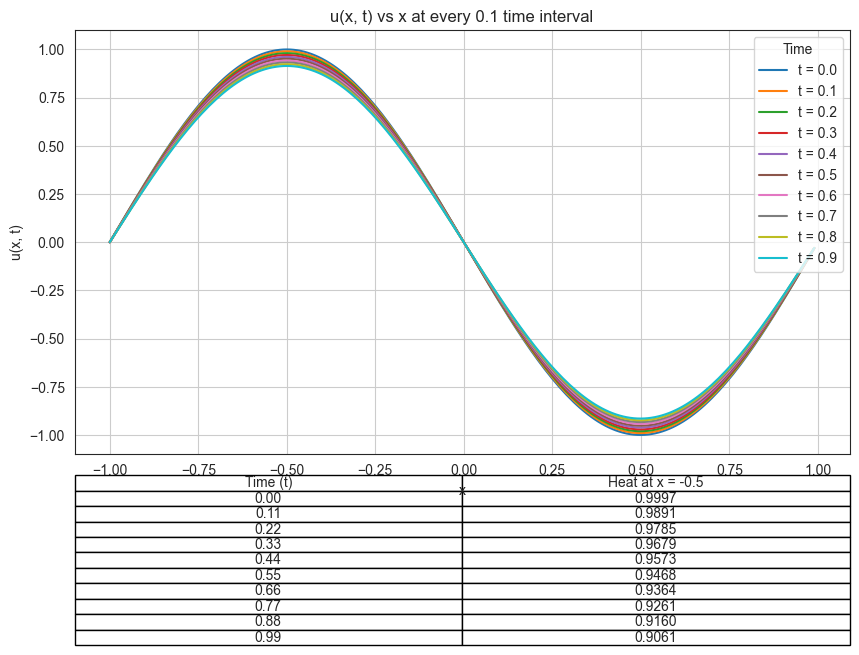

In [2]:
# Assuming y_pred, x, and t are already defined
x = torch.arange(-1, 1, 0.01)  # Shape (200,)
t = torch.arange(0, 1, 0.01)   # Shape (100,)

plt.figure(figsize=(10, 8))  # Make height larger to fit table

# Plot u(x, t) at t = 0.0, 0.1, 0.2, ..., 0.9
for i in range(0, len(t), 10):
    plt.plot(x.numpy(), y_pred[:, i], label=f't = {t[i]:.1f}')

plt.title("u(x, t) vs x at every 0.1 time interval")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend(title="Time", loc='upper right')
plt.grid(True)

# Find the index closest to x = -0.5
x_target = -0.5
idx_x = (torch.abs(x - x_target)).argmin().item()

# Extract heat values at x = -0.5 for every time step
heat_values = y_pred[idx_x, :]  # no detach(), y_pred is numpy array

# Prepare table data: show only 10 evenly spaced time points to keep table readable
num_points = 10
indices = np.linspace(0, len(t)-1, num_points, dtype=int)
table_times = [f"{t[i]:.2f}" for i in indices]
table_values = [f"{heat_values[i]:.4f}" for i in indices]

table_data = list(zip(table_times, table_values))

# Add the table below the plot
plt.table(cellText=table_data,
          colLabels=["Time (t)", f"Heat at x = {x_target}"],
          cellLoc='center',
          loc='bottom',
          bbox=[0.0, -0.45, 1, 0.4])

plt.subplots_adjust(bottom=0.35)

plt.show()

In [3]:
x = torch.tensor([-0.5])
t = torch.tensor([0.99])
u = pinn.predict(x, t)
print(u)

[[0.9060811]]
